In [28]:
# ============================================================
# 1. IMPORTS
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [29]:
# ============================================================
# 2. DEVICE + REPRODUCIBILITY
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using Device: {device}")

np.random.seed(42)
torch.manual_seed(42)


Using Device: cuda


In [30]:
# ============================================================
# 3. HYPERPARAMETERS
# ============================================================
LOOKBACK_GRID = [30, 60, 90]
HIDDEN_SIZE = 128
NUM_LAYERS = 2
DROPOUT = 0.1
LR = 1e-3
EPOCHS = 120
TARGET_COVERAGE = 0.95
LAMBDA_WIDTH = 0.05

# Quantiles used by the model
q_low = 0.025
q_high = 0.975


In [31]:
# ============================================================
# 4. DATA LOADING + FEATURE ENGINEERING
# ============================================================
def load_and_prep_data(filepath="KO.csv"):
    df = pd.read_csv(filepath)
    df.columns = df.columns.str.strip()

    df["Date"] = pd.to_datetime(df["Date"]).dt.tz_localize(None)
    df = df.sort_values("Date").reset_index(drop=True)

    # Feature Engineering
    df["log_return"] = np.log(df["Close"]).diff()
    df["volatility"] = df["log_return"].rolling(5).std()
    df["hl_range"] = (df["High"] - df["Low"]) / df["Close"]

    # Sentiment active impact
    df["sentiment_signed"] = 2 * (df["Scaled_sentiment"] - 0.5)
    df["sentiment_active"] = df["sentiment_signed"] * df["News_flag"]
    df["sentiment_impact"] = df["sentiment_active"] * df["log_return"].shift(1)

    df["target"] = df["Close"].shift(-1)
    df = df.replace([np.inf, -np.inf], np.nan).dropna()

    return df

In [32]:

# ============================================================
# 5. SEQUENCE GENERATOR
# ============================================================
def create_seq(X, y, dates, L):
    Xs, ys, ds = [], [], []
    for i in range(L, len(X)):
        Xs.append(X[i - L:i])
        ys.append(y[i])
        ds.append(dates.iloc[i])
    return np.array(Xs), np.array(ys), np.array(ds)


In [33]:
# ============================================================
# 6. LSTM MODEL + QUANTILE LOSS
# ============================================================
class LSTMModel(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size,
            HIDDEN_SIZE,
            NUM_LAYERS,
            batch_first=True,
            dropout=DROPOUT if NUM_LAYERS > 1 else 0
        )
        self.fc = nn.Linear(HIDDEN_SIZE, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out).squeeze()

def qloss(pred, y, q):
    """Quantile (Pinball) Loss for training."""
    e = y - pred
    return torch.mean(torch.maximum((q - 1) * e, q * e))


In [34]:
# ============================================================
# 7. TRAIN + PREDICT FUNCTION
# ============================================================
def train_and_predict(df, features, lookback, model_name="Model"):
    print(f"\n--- Training {model_name} (Lookback: {lookback}) ---")
    split = int(len(df) * 0.8)

    train_df = df.iloc[:split]

    scalerX = StandardScaler()
    scalerY = StandardScaler()

    scalerX.fit(train_df[features])
    scalerY.fit(train_df[["target"]])

    X = scalerX.transform(df[features])
    y = scalerY.transform(df[["target"]]).ravel()

    X_seq, y_seq, dates = create_seq(X, y, df["Date"], lookback)
    split_date = df["Date"].iloc[split]

    train_mask = dates < split_date
    test_mask = dates >= split_date

    X_train = torch.tensor(X_seq[train_mask], dtype=torch.float32).to(device)
    y_train = torch.tensor(y_seq[train_mask], dtype=torch.float32).to(device)

    X_test = torch.tensor(X_seq[test_mask], dtype=torch.float32).to(device)
    y_test = y_seq[test_mask]
    dates_test = dates[test_mask]

    def train_q(q, q_label):
        model = LSTMModel(X_train.shape[2]).to(device)
        opt = torch.optim.Adam(model.parameters(), lr=LR)

        for epoch in range(EPOCHS):
            pred = model(X_train)
            loss = qloss(pred, y_train, q)

            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

            if (epoch + 1) % 40 == 0 or epoch == 0:
                print(f"[{q_label}] Epoch {epoch+1:03d}/{EPOCHS} | Loss: {loss.item():.4f}")

        return model

    model_low = train_q(q_low, "Low Quantile ")
    model_high = train_q(q_high, "High Quantile")

    with torch.no_grad():
        low = model_low(X_test).cpu().numpy()
        high = model_high(X_test).cpu().numpy()

    # Inverse scaling to actual prices
    low = scalerY.inverse_transform(low.reshape(-1, 1)).ravel()
    high = scalerY.inverse_transform(high.reshape(-1, 1)).ravel()
    y_true = scalerY.inverse_transform(y_test.reshape(-1, 1)).ravel()

    return low, high, y_true, dates_test

In [35]:
# ============================================================
# 8. CALIBRATION FUNCTION
# ============================================================
def calibrate(y, low, high):
    """Calibrate bounds to hit target coverage smoothly."""
    best_scale = 1
    best_score = 1e9

    for s in np.linspace(0.5, 2.0, 40):
        mid = (low + high) / 2
        l = mid - s * (mid - low)
        h = mid + s * (high - mid)

        cov = np.mean((y >= l) & (y <= h))
        width = np.mean(h - l)

        score = abs(cov - TARGET_COVERAGE) + LAMBDA_WIDTH * width

        if score < best_score:
            best_score = score
            best_scale = s

    mid = (low + high) / 2
    cal_low = mid - best_scale * (mid - low)
    cal_high = mid + best_scale * (high - mid)

    return cal_low, cal_high

In [36]:
# ============================================================
# 9. METRIC HELPERS
# ============================================================
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def pinball_loss_np(y_true, y_pred, q):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    return np.mean(np.maximum(q * (y_true - y_pred), (q - 1) * (y_true - y_pred)))


In [37]:

# ============================================================
# 10. DATA + FEATURE SETS
# ============================================================
df = load_and_prep_data("KO.csv")

base_features = ["Close", "log_return", "volatility", "hl_range"]
sent_features = base_features + ["sentiment_active", "sentiment_impact"]

results = []
forecast_data = {}

In [38]:
# ============================================================
# 11. TRAINING LOOP
# ============================================================
for L in LOOKBACK_GRID:
    low1, high1, y_true, dates = train_and_predict(df, base_features, L, "Base LSTM Model")
    low2, high2, _, _ = train_and_predict(df, sent_features, L, "Sentiment LSTM Model")

    low1, high1 = calibrate(y_true, low1, high1)
    low2, high2 = calibrate(y_true, low2, high2)

    mid1, mid2 = (low1 + high1) / 2, (low2 + high2) / 2

    # Coverage and width
    cov1 = np.mean((y_true >= low1) & (y_true <= high1))
    cov2 = np.mean((y_true >= low2) & (y_true <= high2))

    width1 = np.mean(high1 - low1)
    width2 = np.mean(high2 - low2)

    # Point-forecast metrics using midpoint of interval
    mae1 = mean_absolute_error(y_true, mid1)
    mse1 = mean_squared_error(y_true, mid1)
    rmse1 = rmse(y_true, mid1)

    mae2 = mean_absolute_error(y_true, mid2)
    mse2 = mean_squared_error(y_true, mid2)
    rmse2 = rmse(y_true, mid2)

    # Pinball loss for both quantiles
    pbl_low1 = pinball_loss_np(y_true, low1, q_low)
    pbl_high1 = pinball_loss_np(y_true, high1, q_high)

    pbl_low2 = pinball_loss_np(y_true, low2, q_low)
    pbl_high2 = pinball_loss_np(y_true, high2, q_high)

    results.append((
        L,
        cov1, width1, mae1, mse1, rmse1, pbl_low1, pbl_high1,
        cov2, width2, mae2, mse2, rmse2, pbl_low2, pbl_high2
    ))

    forecast_data[L] = {
        "dates": dates,
        "actual": y_true,
        "base_low": low1, "base_high": high1, "base_mid": mid1,
        "sent_low": low2, "sent_high": high2, "sent_mid": mid2
    }


--- Training Base LSTM Model (Lookback: 30) ---
[Low Quantile ] Epoch 001/120 | Loss: 0.3841
[Low Quantile ] Epoch 040/120 | Loss: 0.0158
[Low Quantile ] Epoch 080/120 | Loss: 0.0071
[Low Quantile ] Epoch 120/120 | Loss: 0.0062
[High Quantile] Epoch 001/120 | Loss: 0.4028
[High Quantile] Epoch 040/120 | Loss: 0.0155
[High Quantile] Epoch 080/120 | Loss: 0.0060
[High Quantile] Epoch 120/120 | Loss: 0.0052

--- Training Sentiment LSTM Model (Lookback: 30) ---
[Low Quantile ] Epoch 001/120 | Loss: 0.3882
[Low Quantile ] Epoch 040/120 | Loss: 0.0140
[Low Quantile ] Epoch 080/120 | Loss: 0.0070
[Low Quantile ] Epoch 120/120 | Loss: 0.0060
[High Quantile] Epoch 001/120 | Loss: 0.3580
[High Quantile] Epoch 040/120 | Loss: 0.0161
[High Quantile] Epoch 080/120 | Loss: 0.0096
[High Quantile] Epoch 120/120 | Loss: 0.0051

--- Training Base LSTM Model (Lookback: 60) ---
[Low Quantile ] Epoch 001/120 | Loss: 0.3577
[Low Quantile ] Epoch 040/120 | Loss: 0.0180
[Low Quantile ] Epoch 080/120 | Loss: 

In [39]:
# ============================================================
# 12. COMPARISON PRINTOUT
# ============================================================
print("\n" + "=" * 132)
print(f"{'FINAL COMPARISON (Base vs Sentiment - LSTM)':^132}")
print("=" * 132)
print(
    f"{'Lookback':<9} | "
    f"{'Base Cov':<8} | {'Base Wdth':<9} | {'Base MAE':<9} | {'Base MSE':<9} | {'Base RMSE':<9} | {'Base PB-L':<10} | {'Base PB-H':<10} || "
    f"{'Sent Cov':<8} | {'Sent Wdth':<9} | {'Sent MAE':<9} | {'Sent MSE':<9} | {'Sent RMSE':<9} | {'Sent PB-L':<10} | {'Sent PB-H':<10}"
)
print("-" * 132)

for r in results:
    print(
        f"{r[0]:<9} | "
        f"{r[1]:<8.4f} | {r[2]:<9.4f} | {r[3]:<9.4f} | {r[4]:<9.4f} | {r[5]:<9.4f} | {r[6]:<10.4f} | {r[7]:<10.4f} || "
        f"{r[8]:<8.4f} | {r[9]:<9.4f} | {r[10]:<9.4f} | {r[11]:<9.4f} | {r[12]:<9.4f} | {r[13]:<10.4f} | {r[14]:<10.4f}"
    )

# Optional summary averages across lookbacks
base_avg = np.mean(np.array([[r[1], r[2], r[3], r[4], r[5], r[6], r[7]] for r in results]), axis=0)
sent_avg = np.mean(np.array([[r[8], r[9], r[10], r[11], r[12], r[13], r[14]] for r in results]), axis=0)

print("\n" + "=" * 90)
print(f"{'AVERAGE ACROSS LOOKBACKS':^90}")
print("=" * 90)
print(f"Base      -> Coverage: {base_avg[0]:.4f}, Width: {base_avg[1]:.4f}, MAE: {base_avg[2]:.4f}, MSE: {base_avg[3]:.4f}, RMSE: {base_avg[4]:.4f}, Pinball-L: {base_avg[5]:.4f}, Pinball-H: {base_avg[6]:.4f}")
print(f"Sentiment -> Coverage: {sent_avg[0]:.4f}, Width: {sent_avg[1]:.4f}, MAE: {sent_avg[2]:.4f}, MSE: {sent_avg[3]:.4f}, RMSE: {sent_avg[4]:.4f}, Pinball-L: {sent_avg[5]:.4f}, Pinball-H: {sent_avg[6]:.4f}")



                                            FINAL COMPARISON (Base vs Sentiment - LSTM)                                             
Lookback  | Base Cov | Base Wdth | Base MAE  | Base MSE  | Base RMSE | Base PB-L  | Base PB-H  || Sent Cov | Sent Wdth | Sent MAE  | Sent MSE  | Sent RMSE | Sent PB-L  | Sent PB-H 
------------------------------------------------------------------------------------------------------------------------------------
30        | 0.9299   | 8.5023    | 2.1576    | 7.4136    | 2.7228    | 0.1555     | 0.0975     || 0.9116   | 7.6009    | 2.0215    | 6.5427    | 2.5579    | 0.1415     | 0.1132    
60        | 0.9369   | 9.0259    | 2.3559    | 8.6007    | 2.9327    | 0.1675     | 0.1003     || 0.9257   | 7.8381    | 1.8895    | 5.8469    | 2.4180    | 0.1394     | 0.1096    
90        | 0.9299   | 8.3077    | 2.2318    | 7.6284    | 2.7619    | 0.1567     | 0.0948     || 0.9397   | 7.8637    | 1.9501    | 6.1874    | 2.4874    | 0.1426     | 0.0878    

        

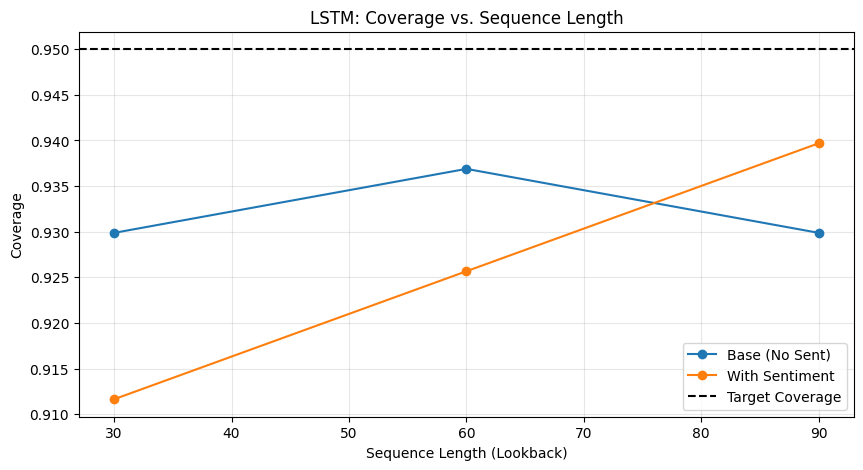

In [40]:
# ============================================================
# 13. PLOTS
# ============================================================

# Plot 1: Coverage vs Lookback
plt.figure(figsize=(10, 5))
plt.plot([r[0] for r in results], [r[1] for r in results], marker='o', label="Base (No Sent)")
plt.plot([r[0] for r in results], [r[8] for r in results], marker='o', label="With Sentiment")
plt.axhline(TARGET_COVERAGE, color='black', linestyle='--', label="Target Coverage")
plt.xlabel("Sequence Length (Lookback)")
plt.ylabel("Coverage")
plt.title("LSTM: Coverage vs. Sequence Length")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


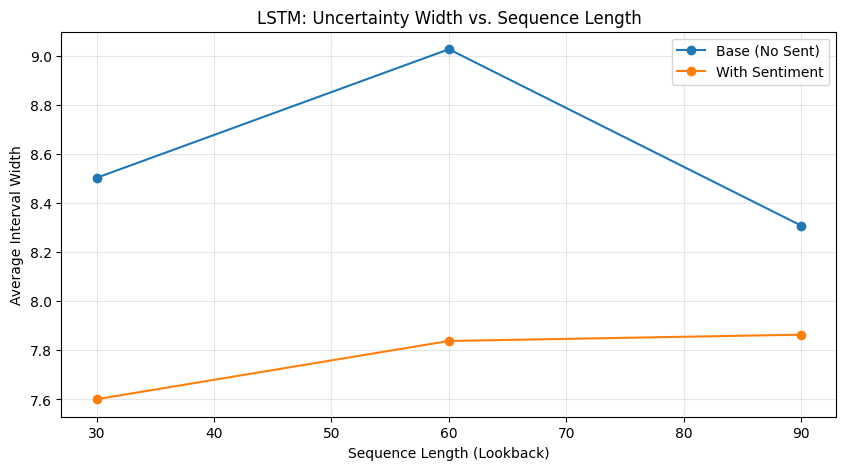

In [41]:
# Plot 2: Width vs Lookback
plt.figure(figsize=(10, 5))
plt.plot([r[0] for r in results], [r[2] for r in results], marker='o', label="Base (No Sent)")
plt.plot([r[0] for r in results], [r[9] for r in results], marker='o', label="With Sentiment")
plt.xlabel("Sequence Length (Lookback)")
plt.ylabel("Average Interval Width")
plt.title("LSTM: Uncertainty Width vs. Sequence Length")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


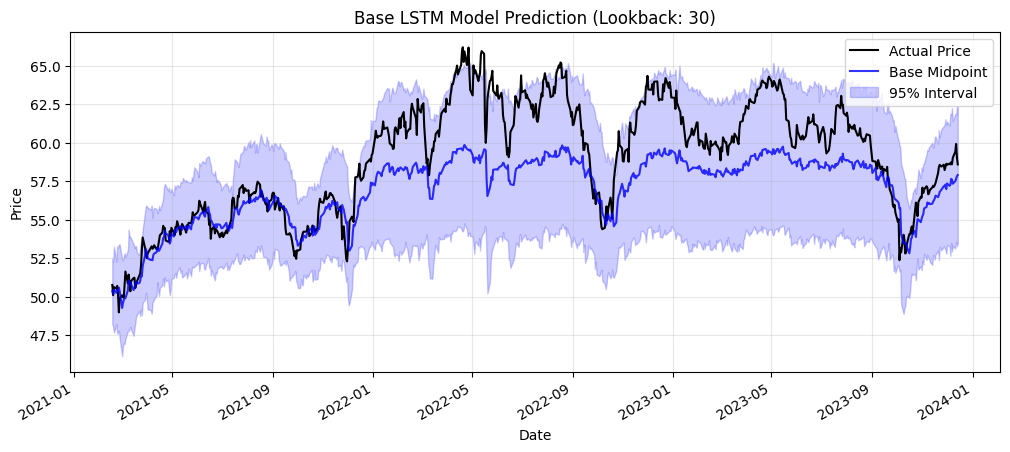

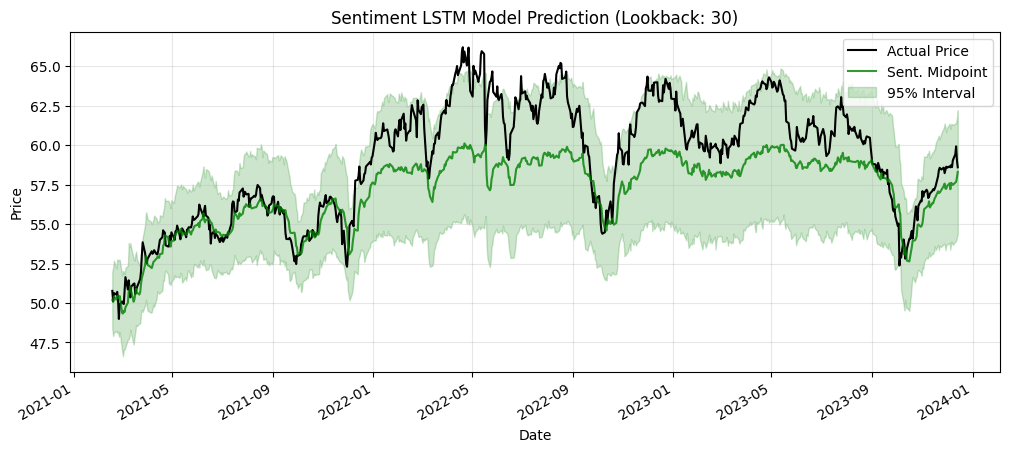

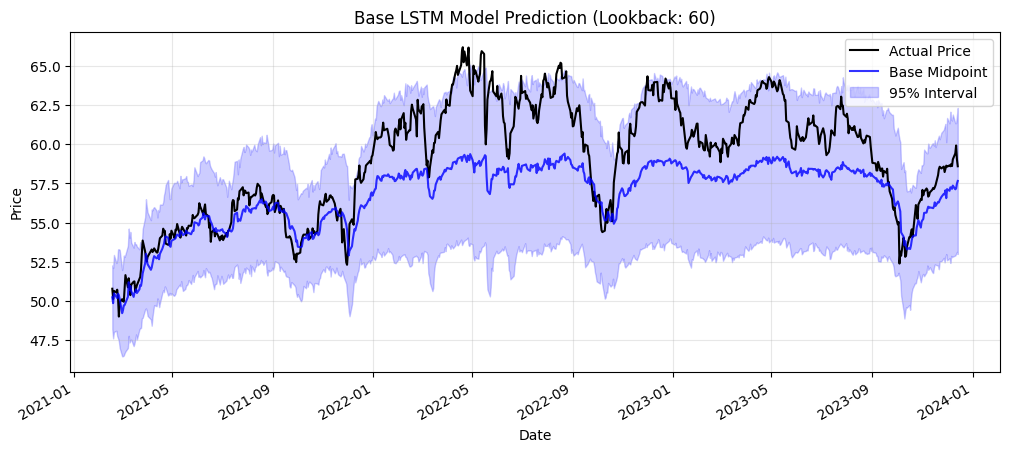

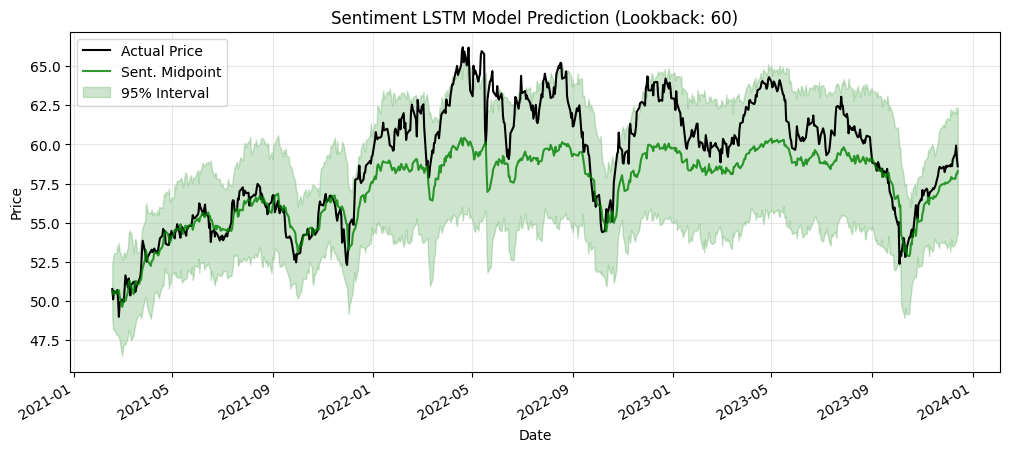

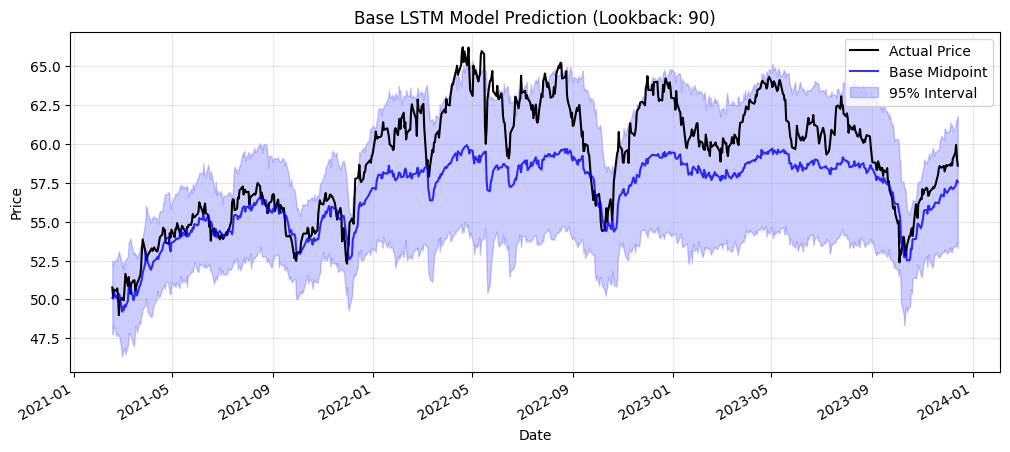

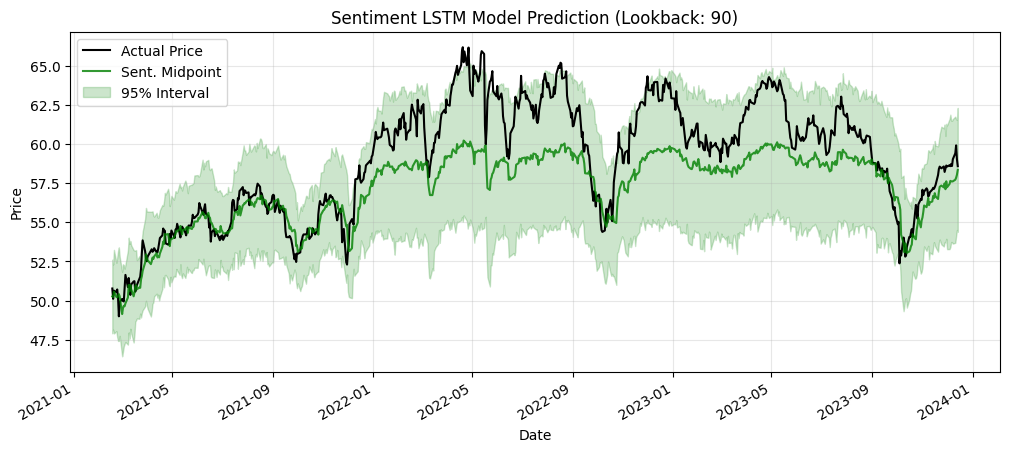

In [42]:
# Plot 3 and 4: Forecast visualizations for each model and each lookback
for L in LOOKBACK_GRID:
    data = forecast_data[L]

    plt.figure(figsize=(12, 5))
    plt.plot(data["dates"], data["actual"], label="Actual Price", color='black', linewidth=1.5)
    plt.plot(data["dates"], data["base_mid"], label="Base Midpoint", color='blue', alpha=0.8)
    plt.fill_between(data["dates"], data["base_low"], data["base_high"], color='blue', alpha=0.2, label="95% Interval")
    plt.title(f"Base LSTM Model Prediction (Lookback: {L})")
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.gcf().autofmt_xdate()
    plt.show()

    plt.figure(figsize=(12, 5))
    plt.plot(data["dates"], data["actual"], label="Actual Price", color='black', linewidth=1.5)
    plt.plot(data["dates"], data["sent_mid"], label="Sent. Midpoint", color='green', alpha=0.8)
    plt.fill_between(data["dates"], data["sent_low"], data["sent_high"], color='green', alpha=0.2, label="95% Interval")
    plt.title(f"Sentiment LSTM Model Prediction (Lookback: {L})")
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.gcf().autofmt_xdate()
    plt.show()



In [43]:
# ============================================================
# 14. ERROR METRICS COMPARISON PLOTS
# ============================================================

lookbacks = [r[0] for r in results]

# Extract metrics
base_mae = [r[3] for r in results]
base_mse = [r[4] for r in results]
base_rmse = [r[5] for r in results]
base_pbl = [r[6] for r in results]
base_pbh = [r[7] for r in results]

sent_mae = [r[10] for r in results]
sent_mse = [r[11] for r in results]
sent_rmse = [r[12] for r in results]
sent_pbl = [r[13] for r in results]
sent_pbh = [r[14] for r in results]


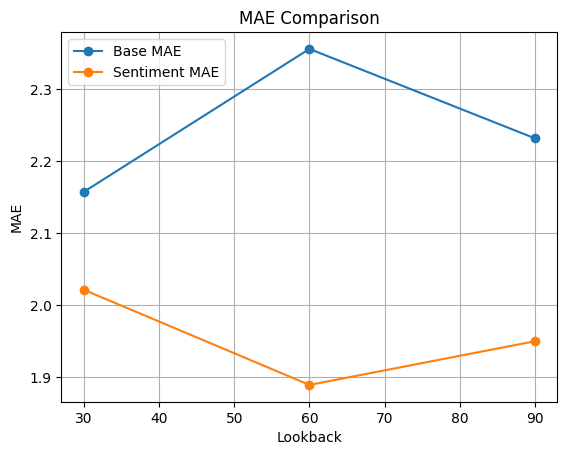

In [44]:

# -----------------------------
# MAE Plot
# -----------------------------
plt.figure()
plt.plot(lookbacks, base_mae, marker='o', label="Base MAE")
plt.plot(lookbacks, sent_mae, marker='o', label="Sentiment MAE")
plt.title("MAE Comparison")
plt.xlabel("Lookback")
plt.ylabel("MAE")
plt.legend()
plt.grid()
plt.show()

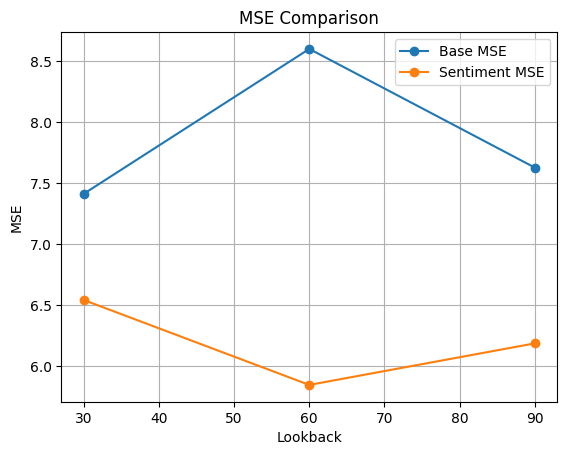

In [45]:
# -----------------------------
# MSE Plot
# -----------------------------
plt.figure()
plt.plot(lookbacks, base_mse, marker='o', label="Base MSE")
plt.plot(lookbacks, sent_mse, marker='o', label="Sentiment MSE")
plt.title("MSE Comparison")
plt.xlabel("Lookback")
plt.ylabel("MSE")
plt.legend()
plt.grid()
plt.show()


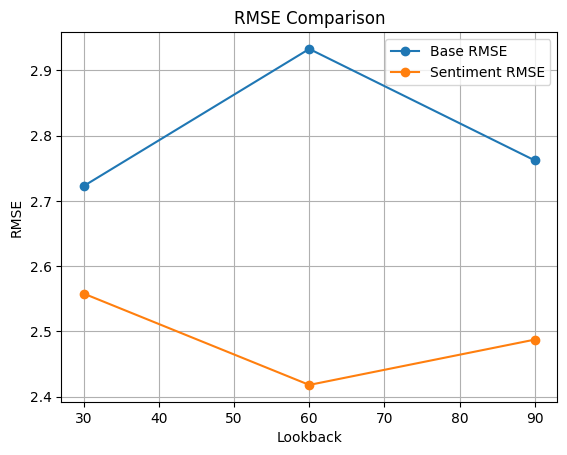

In [46]:
# -----------------------------
# RMSE Plot
# -----------------------------
plt.figure()
plt.plot(lookbacks, base_rmse, marker='o', label="Base RMSE")
plt.plot(lookbacks, sent_rmse, marker='o', label="Sentiment RMSE")
plt.title("RMSE Comparison")
plt.xlabel("Lookback")
plt.ylabel("RMSE")
plt.legend()
plt.grid()
plt.show()


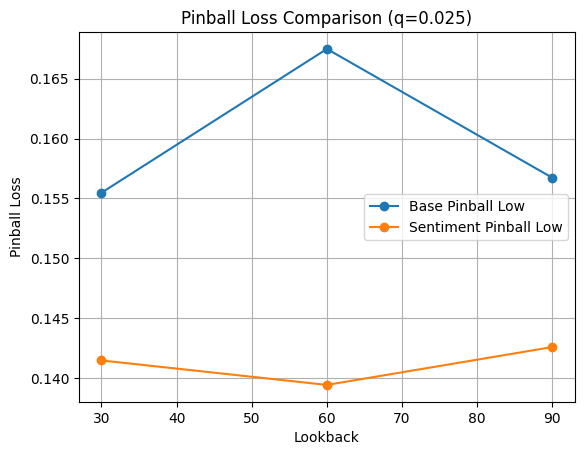

In [47]:
# -----------------------------
# Pinball Loss (Lower Quantile)
# -----------------------------
plt.figure()
plt.plot(lookbacks, base_pbl, marker='o', label="Base Pinball Low")
plt.plot(lookbacks, sent_pbl, marker='o', label="Sentiment Pinball Low")
plt.title(f"Pinball Loss Comparison (q={q_low})")
plt.xlabel("Lookback")
plt.ylabel("Pinball Loss")
plt.legend()
plt.grid()
plt.show()

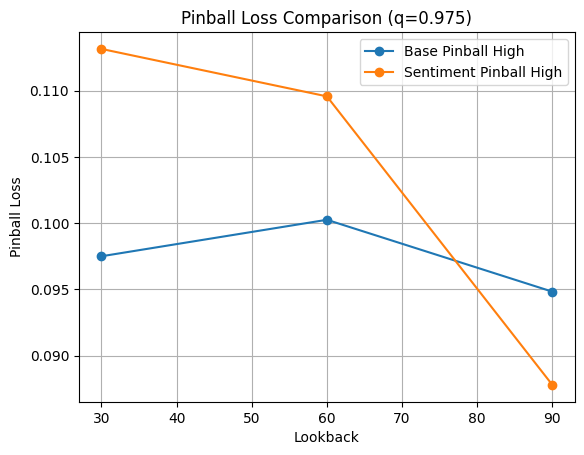

In [48]:
# -----------------------------
# Pinball Loss (Upper Quantile)
# -----------------------------
plt.figure()
plt.plot(lookbacks, base_pbh, marker='o', label="Base Pinball High")
plt.plot(lookbacks, sent_pbh, marker='o', label="Sentiment Pinball High")
plt.title(f"Pinball Loss Comparison (q={q_high})")
plt.xlabel("Lookback")
plt.ylabel("Pinball Loss")
plt.legend()
plt.grid()
plt.show()